In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from model.KMeans import kmeans

# The file uses whitespace, not commas
data = np.loadtxt(
    "data/homework_files/kmtest.csv",
    encoding="utf-8-sig"
)

k = 4

#My implementation of KMeans
my_labels, my_centroids = kmeans(data, k)

#SK-Learn's KMeans implementation for comparison
sklearn_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

sklearn_labels = sklearn_model.fit_predict(data)

print("My centroids:")
print(my_centroids)

print("\nScikit-learn centroids:")
print(sklearn_model.cluster_centers_)

my_inertia = np.sum(
    (data - my_centroids[my_labels]) ** 2
)

print("\nMy inertia:", my_inertia)
print("Scikit-learn inertia:", sklearn_model.inertia_)

My centroids:
[[15.5         5.        ]
 [ 9.8         9.6       ]
 [ 3.16666667  4.        ]
 [ 9.5         4.5       ]]

Scikit-learn centroids:
[[ 9.5         4.5       ]
 [15.5         5.        ]
 [ 3.16666667  4.        ]
 [ 9.8         9.6       ]]

My inertia: 18.333333333333332
Scikit-learn inertia: 18.333333333333332


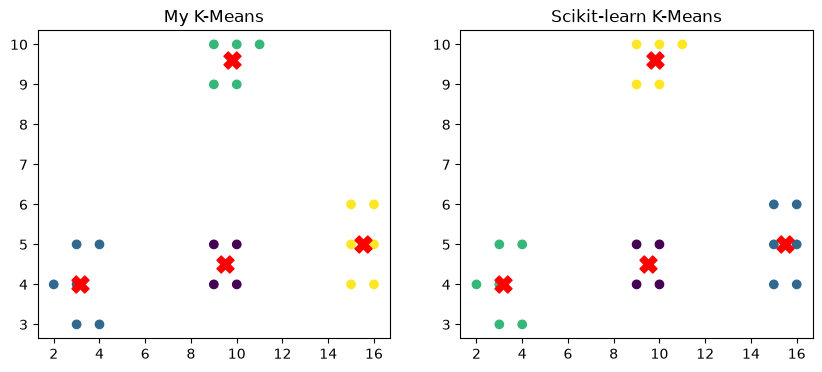

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 0], data[:, 1], c=my_labels)
axes[0].scatter(
    my_centroids[:, 0],
    my_centroids[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[0].set_title("My K-Means")

axes[1].scatter(data[:, 0], data[:, 1], c=sklearn_labels)
axes[1].scatter(
    sklearn_model.cluster_centers_[:, 0],
    sklearn_model.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[1].set_title("Scikit-learn K-Means")

plt.show()

In [8]:
import importlib
import agents.document_agent as document_agent

importlib.reload(document_agent)

chunks = document_agent.process_documents(
    "data/pdf/transformers"
)

print(len(chunks))

Processed Attention.pdf, page 1: 4 chunks
Processed Attention.pdf, page 2: 6 chunks
Processed Attention.pdf, page 3: 3 chunks
Processed Attention.pdf, page 4: 4 chunks
Processed Attention.pdf, page 5: 4 chunks
Processed Attention.pdf, page 6: 5 chunks
Processed Attention.pdf, page 7: 5 chunks
Processed Attention.pdf, page 8: 4 chunks
Processed Attention.pdf, page 9: 4 chunks
Processed Attention.pdf, page 10: 4 chunks
Processed Attention.pdf, page 11: 5 chunks
Processed Attention.pdf, page 12: 5 chunks
Processed Attention.pdf, page 13: 2 chunks
Processed Attention.pdf, page 14: 2 chunks
Processed Attention.pdf, page 15: 2 chunks
Processed Bert.pdf, page 1: 5 chunks
Processed Bert.pdf, page 2: 6 chunks
Processed Bert.pdf, page 3: 5 chunks
Processed Bert.pdf, page 4: 7 chunks
Processed Bert.pdf, page 5: 5 chunks
Processed Bert.pdf, page 6: 6 chunks
Processed Bert.pdf, page 7: 5 chunks
Processed Bert.pdf, page 8: 6 chunks
Processed Bert.pdf, page 9: 6 chunks
Processed Bert.pdf, page 10: 6 

In [9]:
from agents.document_agent import process_documents
from agents.embedding_agent import create_embeddings

In [10]:
chunks = process_documents(
    "data/pdf/transformers"
)

print("Chunks:", len(chunks))
print(chunks[0]["text"][:300])

Processed Attention.pdf, page 1: 4 chunks
Processed Attention.pdf, page 2: 6 chunks
Processed Attention.pdf, page 3: 3 chunks
Processed Attention.pdf, page 4: 4 chunks
Processed Attention.pdf, page 5: 4 chunks
Processed Attention.pdf, page 6: 5 chunks
Processed Attention.pdf, page 7: 5 chunks
Processed Attention.pdf, page 8: 4 chunks
Processed Attention.pdf, page 9: 4 chunks
Processed Attention.pdf, page 10: 4 chunks
Processed Attention.pdf, page 11: 5 chunks
Processed Attention.pdf, page 12: 5 chunks
Processed Attention.pdf, page 13: 2 chunks
Processed Attention.pdf, page 14: 2 chunks
Processed Attention.pdf, page 15: 2 chunks
Processed Bert.pdf, page 1: 5 chunks
Processed Bert.pdf, page 2: 6 chunks
Processed Bert.pdf, page 3: 5 chunks
Processed Bert.pdf, page 4: 7 chunks
Processed Bert.pdf, page 5: 5 chunks
Processed Bert.pdf, page 6: 6 chunks
Processed Bert.pdf, page 7: 5 chunks
Processed Bert.pdf, page 8: 6 chunks
Processed Bert.pdf, page 9: 6 chunks
Processed Bert.pdf, page 10: 6 

In [ ]:
embeddings = create_embeddings(chunks)

print("Embedding shape:", embeddings.shape)

In [ ]:
labels, centroids = kmeans(
    embeddings,
    k=5
)

print("Labels shape:", labels.shape)
print("Centroids shape:", centroids.shape)
print("First 10 labels:", labels[:10])
print("First 10 centroids:", centroids[:10])